In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [11]:
# LOAD DATA 
df = pd.read_csv(r"C:\Users\Hp\Documents\AmesHousing.csv")
print("HOUSE PRICE PREDICTION — LINEAR REGRESSION")
print(f"\nDataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.sample(5)

HOUSE PRICE PREDICTION — LINEAR REGRESSION

Dataset shape: 2930 rows × 82 columns


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1408,1409,905427050,50,RL,66.0,21780,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,185000
169,170,902102100,50,RM,60.0,4800,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,1,2010,COD,Abnorml,80400
686,687,535454160,50,RL,60.0,8064,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,8,2009,COD,Abnorml,135000
126,127,534430080,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
90,91,533130020,60,RL,107.0,10186,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,190000


In [12]:
# SELECT FEATURES 
# Gr Liv Area   → Above-ground living area (square footage)
# Bedroom AbvGr → Number of bedrooms above ground
# Full Bath     → Full bathrooms
# Half Bath     → Half bathrooms

features = ['Gr Liv Area', 'Bedroom AbvGr', 'Full Bath', 'Half Bath']
target   = 'SalePrice'

data = df[features + [target]].dropna()
print(f"Rows after removing missing values: {len(data)}")

Rows after removing missing values: 2930


In [35]:
# EXPLORATORY DATA ANALYSIS 
print("Feature Statistics:")
print(data.describe().round(2))

print("\nCorrelation with SalePrice:")
print(data.corr()[target].round(4))

Feature Statistics:
       Gr Liv Area  Bedroom AbvGr  Full Bath  Half Bath  SalePrice
count      2930.00        2930.00    2930.00    2930.00    2930.00
mean       1499.69           2.85       1.57       0.38  180796.06
std         505.51           0.83       0.55       0.50   79886.69
min         334.00           0.00       0.00       0.00   12789.00
25%        1126.00           2.00       1.00       0.00  129500.00
50%        1442.00           3.00       2.00       0.00  160000.00
75%        1742.75           3.00       2.00       1.00  213500.00
max        5642.00           8.00       4.00       2.00  755000.00

Correlation with SalePrice:
Gr Liv Area      0.7068
Bedroom AbvGr    0.1439
Full Bath        0.5456
Half Bath        0.2851
SalePrice        1.0000
Name: SalePrice, dtype: float64


In [15]:
# SPLIT FEATURES & TARGET 
X = data[features]
y = data[target]

In [17]:
# TRAIN / TEST SPLIT (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTraining samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")


Training samples : 2344
Testing  samples : 586


In [18]:
# FEATURE SCALING 
scaler     = StandardScaler()
X_train_s  = scaler.fit_transform(X_train)
X_test_s   = scaler.transform(X_test)

In [24]:
# TRAIN LINEAR REGRESSION MODEL 
model = LinearRegression()
model.fit(X_train_s, y_train)
 
print("Model Coefficients:")
print(f"Intercept : ${model.intercept_:,.2f}")
for feature, coef in zip(features, model.coef_):
    print(f"  {feature:<20} : ${coef:>12,.2f}")

Model Coefficients:
Intercept : $178,582.21
  Gr Liv Area          : $   56,418.17
  Bedroom AbvGr        : $  -23,665.08
  Full Bath            : $   14,761.96
  Half Bath            : $    1,496.99


In [25]:
# PREDICTIONS 
y_pred = model.predict(X_test_s)
 
# EVALUATION METRICS 
r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
print("MODEL PERFORMANCE METRICS:")
print(f"  R² Score  : {r2:.4f}  ({r2*100:.1f}% variance explained)")
print(f"  RMSE      : ${rmse:,.2f}")
print(f"  MAE       : ${mae:,.2f}")

MODEL PERFORMANCE METRICS:
  R² Score  : 0.6125  (61.3% variance explained)
  RMSE      : $55,736.20
  MAE       : $37,157.94


In [36]:
# SAMPLE PREDICTIONS 
print("Sample Predictions vs Actual Prices:\n")
print(f"{'SqFt':>6} {'Beds':>5} {'Bath':>5} {'HBath':>6} "
      f"{'Predicted':>12} {'Actual':>12} {'Error':>10}")
print("-" * 60)
 
sample_X = X_test.iloc[:10]
sample_y = y_test.iloc[:10]
sample_pred = model.predict(scaler.transform(sample_X))
 
for i in range(10):
    row   = sample_X.iloc[i]
    pred  = sample_pred[i]
    actual = sample_y.iloc[i]
    error = pred - actual
    print(f"{int(row['Gr Liv Area']):>6} "
          f"{int(row['Bedroom AbvGr']):>5} "
          f"{int(row['Full Bath']):>5} "
          f"{int(row['Half Bath']):>6} "
          f"${pred:>11,.0f} "
          f"${actual:>11,.0f} "
          f"${error:>+10,.0f}")
 

Sample Predictions vs Actual Prices:

  SqFt  Beds  Bath  HBath    Predicted       Actual      Error
------------------------------------------------------------
  1666     3     1      0 $    177,466 $    161,000 $   +16,466
  1030     3     1      1 $    109,340 $    116,000 $    -6,660
  1724     3     2      1 $    213,689 $    196,500 $   +17,189
   990     3     1      0 $    101,870 $    123,600 $   -21,730
   919     2     1      0 $    122,784 $    126,000 $    -3,216
  1326     3     2      0 $    166,185 $    174,190 $    -8,005
  1020     1     1      0 $    162,933 $    200,000 $   -37,067
  1456     3     2      1 $    183,719 $    148,500 $   +35,219
   704     2     1      0 $     98,741 $     88,750 $    +9,991
  2520     5     2      1 $    244,996 $    409,900 $  -164,904


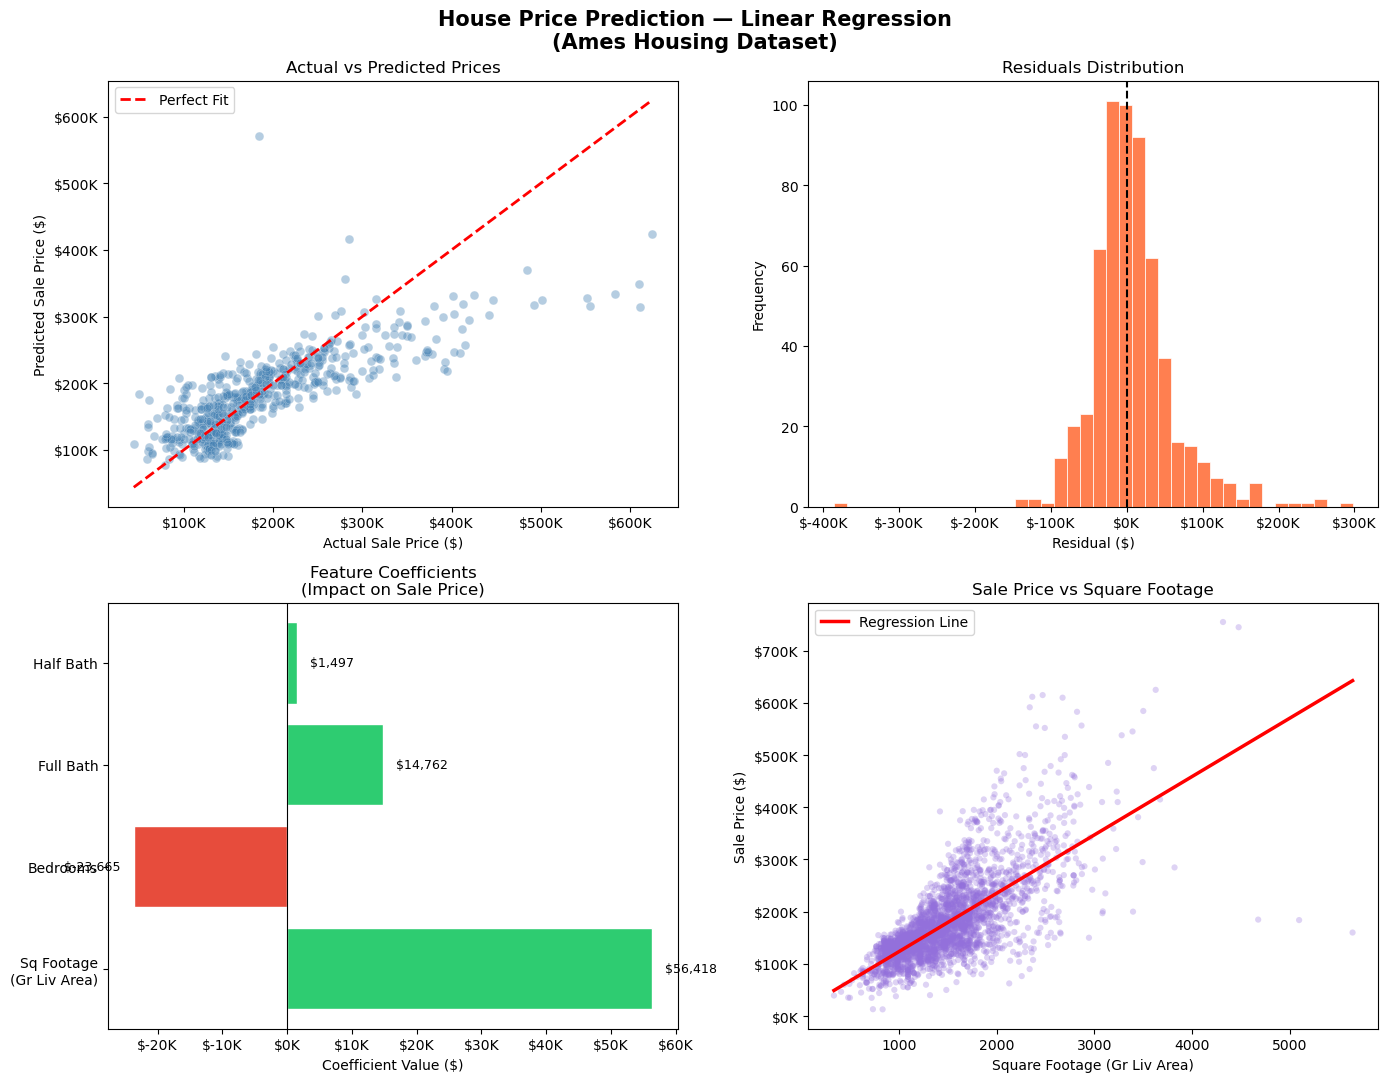


Plot saved as 'house_price_prediction.png'


In [29]:
# VISUALIZATIONS
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('House Price Prediction — Linear Regression\n(Ames Housing Dataset)',
             fontsize=15, fontweight='bold', y=0.98)
 
# Plot 1: Actual vs Predicted
ax1 = axes[0, 0]
ax1.scatter(y_test, y_pred, alpha=0.4, color='steelblue', edgecolors='white',
            linewidth=0.3, s=40)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')
ax1.set_xlabel('Actual Sale Price ($)')
ax1.set_ylabel('Predicted Sale Price ($)')
ax1.set_title('Actual vs Predicted Prices')
ax1.legend()
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))


# Plot 2: Residuals Distribution
ax2 = axes[0, 1]
residuals = y_test - y_pred
ax2.hist(residuals, bins=40, color='coral', edgecolor='white', linewidth=0.5)
ax2.axvline(0, color='black', linestyle='--', lw=1.5)
ax2.set_xlabel('Residual ($)')
ax2.set_ylabel('Frequency')
ax2.set_title('Residuals Distribution')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))


# Plot 3: Feature Coefficients
ax3 = axes[1, 0]
feature_labels = ['Sq Footage\n(Gr Liv Area)', 'Bedrooms', 'Full Bath', 'Half Bath']
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in model.coef_]
bars = ax3.barh(feature_labels, model.coef_, color=colors, edgecolor='white')
ax3.axvline(0, color='black', linewidth=0.8)
ax3.set_xlabel('Coefficient Value ($)')
ax3.set_title('Feature Coefficients\n(Impact on Sale Price)')
for bar, val in zip(bars, model.coef_):
    ax3.text(val + (2000 if val > 0 else -2000), bar.get_y() + bar.get_height()/2,
             f'${val:,.0f}', va='center', ha='left' if val > 0 else 'right', fontsize=9)
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))


# Plot 4: Sale Price vs Square Footage (scatter with regression line)
ax4 = axes[1, 1]
ax4.scatter(data['Gr Liv Area'], data['SalePrice'], alpha=0.3, color='mediumpurple',
            s=20, edgecolors='none')
# Fit line for sqft only
sqft_range = np.linspace(data['Gr Liv Area'].min(), data['Gr Liv Area'].max(), 100)
# Use average values for other features
avg_bed   = data['Bedroom AbvGr'].mean()
avg_bath  = data['Full Bath'].mean()
avg_hbath = data['Half Bath'].mean()
line_X = pd.DataFrame({
    'Gr Liv Area': sqft_range,
    'Bedroom AbvGr': avg_bed,
    'Full Bath': avg_bath,
    'Half Bath': avg_hbath
})
line_pred = model.predict(scaler.transform(line_X))
ax4.plot(sqft_range, line_pred, 'r-', lw=2.5, label='Regression Line')
ax4.set_xlabel('Square Footage (Gr Liv Area)')
ax4.set_ylabel('Sale Price ($)')
ax4.set_title('Sale Price vs Square Footage')
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax4.legend()
 
plt.tight_layout()
plt.savefig('house_price_prediction.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved as 'house_price_prediction.png'")

In [33]:
# PREDICT A CUSTOM HOUSE 
print("Predict Your Own House:")

try:
    sqft      = float(input("Enter Square Footage       : "))
    bedrooms  = float(input("Enter Number of Bedrooms   : "))
    full_bath = float(input("Enter Number of Full Baths : "))
    half_bath = float(input("Enter Number of Half Baths : "))
    custom_house = pd.DataFrame({
        'Gr Liv Area':   [sqft],
        'Bedroom AbvGr': [bedrooms],
        'Full Bath':     [full_bath],
        'Half Bath':     [half_bath],
    })
    custom_scaled = scaler.transform(custom_house)
    custom_pred   = model.predict(custom_scaled)[0]
    print(f"Predicted Price: ${custom_pred:,.0f}")

except ValueError:
    print("Invalid input! Please enter numeric values only.")

Predict Your Own House:


Enter Square Footage       :  2000
Enter Number of Bedrooms   :  6
Enter Number of Full Baths :  3
Enter Number of Half Baths :  2


Predicted Price: $187,730
